# 1. 데이터 전처리

사용 데이터셋

서울시 주민등록인구(내국인, 세별, 구별)
https://data.seoul.go.kr/dataList/10719/S/2/datasetView.do

서울시 일반음식점 인허가 정보
https://data.seoul.go.kr/dataList/OA-16094/S/1/datasetView.do?utm_source=chatgpt.com

서울시 약국 인허가 정보
https://data.seoul.go.kr/dataList/OA-16484/S/1/datasetView.do?utm_source=chatgpt.com

서울시 병의원 위치 정보
https://data.seoul.go.kr/dataList/OA-20337/S/1/datasetView.do

서울시 안정상비의약품 판매업소 인허가 정보
https://data.seoul.go.kr/dataList/OA-16483/S/1/datasetView.do?utm_source=chatgpt.com

In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import folium
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# 폴더 경로
DATA_DIR = "data"

# 파일 목록 확인
print("data 폴더:", os.listdir(DATA_DIR))

data 폴더: ['.ipynb_checkpoints', '서울시 병의원 위치 정보.csv', '서울시 약국 인허가 정보.csv', '서울시 일반음식점 인허가 정보.csv', '서울시_상비약품판매업소.csv', '서울시_인구_구별.csv']


In [2]:
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
csv_files

for file in csv_files:
    path = os.path.join(DATA_DIR, file)
    print("=" * 80)
    print(file)
    
    try:
        df = pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="cp949")
    
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    display(df.head())


서울시 병의원 위치 정보.csv
shape: (22239, 34)
columns: ['기관ID', '주소', '병원분류', '병원분류명', '응급의료기관코드', '응급의료기관코드명', '응급실운영여부(1/2)', '비고', '기관설명상세', '간이약도', '기관명', '대표전화1', '응급실전화', '진료시간(월요일)C', '진료시간(화요일)C', '진료시간(수요일)C', '진료시간(목요일)C', '진료시간(금요일)C', '진료시간(토요일)C', '진료시간(일요일)C', '진료시간(공휴일)C', '진료시간(월요일)S', '진료시간(화요일)S', '진료시간(수요일)S', '진료시간(목요일)S', '진료시간(금요일)S', '진료시간(토요일)S', '진료시간(일요일)S', '진료시간(공휴일)S', '우편번호1', '우편번호2', '병원경도', '병원위도', '작업시간']


,기관ID,주소,병원분류,병원분류명,응급의료기관코드,응급의료기관코드명,응급실운영여부(1/2),비고,기관설명상세,간이약도,...,진료시간(목요일)S,진료시간(금요일)S,진료시간(토요일)S,진료시간(일요일)S,진료시간(공휴일)S,우편번호1,우편번호2,병원경도,병원위도,작업시간
0,A1120837,"서울특별시 금천구 벚꽃로 286, 삼성리더스타워 111~114호 (가산동)",C,의원,G099,응급의료기관 이외,2,"외과: 상시진료, 내과는 당분간 휴진","서울시 송파구 문정동 장지동 법조단지 위례 가락동 가락시장역 위치, 삼성서울병원 외...",방이역 1번출구 바로옆 굿모닝 신한증권 뒷건물,...,900,900,900.0,1000.0,1000.0,85,11,126.884122,37.480394,2022-04-07 14:55:00.0
1,A1104130,"서울특별시 강남구 도산대로 118 (논현동, 신사빌딩 2층)",C,의원,G099,응급의료기관 이외,2,비만클리닉,"365일 진료, 국민건강보험공단 검진 지정병원 점심시간 13~14시",신사역 1번 출구 인근,...,1100,1100,1100.0,900.0,900.0,60,38,127.021809,37.516604,2021-06-07 14:54:49.0
2,A1121126,"서울특별시 양천구 목동동로 293, 현대41타워 406,407호 (목동)",C,의원,G099,응급의료기관 이외,2,점심시간 13:00~14:00 접수는 마감 30분 전까지,안녕하세요 마디로한의원 송파거여점입니다. 5호선 거여역 7번 출구 바로 앞에 위치해...,강동역 2-1번 출구,...,900,900,900.0,900.0,900.0,79,97,126.875772,37.528178,2026-04-07 14:53:26.0
3,A1116728,"서울특별시 양천구 목동동로 293, 현대41타워 504,505호 (목동)",C,의원,G099,응급의료기관 이외,2,"토요일 : 예약환자[수술,드림렌즈]만 진료",안녕하세요 마디로한의원 송파거여점입니다. 5호선 거여역 7번 출구 바로 앞에 위치해...,CBS기독교방송 옆 건물,...,930,930,930.0,900.0,900.0,79,97,126.875772,37.528178,2026-04-07 14:53:26.0
4,A1117873,"서울특별시 관악구 신원로 38, 5층 (신림동, 청암빌딩)",N,치과의원,G099,응급의료기관 이외,2,대표번호1 지역번호 추가20170118150453,"서울시 송파구 문정동 장지동 법조단지 위례 가락동 가락시장역 위치, 삼성서울병원 외...",서월치안센터 인근 청암빌딩 5층,...,1400,1000,1000.0,1000.0,1000.0,87,76,126.929377,37.481918,2022-01-07 14:54:55.0


서울시 약국 인허가 정보.csv
shape: (5876, 24)
columns: ['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태코드', '영업상태명', '상세영업상태코드', '상세영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자', '전화번호', '소재지우편번호', '지번주소', '도로명주소', '도로명우편번호', '사업장명', '최종수정일자', '데이터갱신구분', '데이터갱신일자', '좌표정보(X)', '좌표정보(Y)', '약국영업면적', '지정일자']


,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,도로명주소,도로명우편번호,사업장명,최종수정일자,데이터갱신구분,데이터갱신일자,좌표정보(X),좌표정보(Y),약국영업면적,지정일자
0,3030000,PHMD120193030033084000019,2019-11-04,,1,영업/정상,13,영업중,,,...,"서울특별시 성동구 왕십리로 320, 1층 101호 (도선동)",04709,건강한약국,2023-01-25 11:46:43,I,2026-03-26 22:34:30,202967.042456635,451118.809600324,35.0,2019-11-04
1,3030000,PHMD120203030033084000001,2020-01-21,,1,영업/정상,13,영업중,,,...,"서울특별시 성동구 왕십리로 50, 지하 1층 (성수동1가)",04778,서울숲팜프라자약국,2020-01-21 09:04:32,I,2026-03-26 22:34:30,203903.353552789,448846.820248719,29.0,2020-01-21
2,3030000,PHMD120203030033084000002,2020-07-29,,1,영업/정상,13,영업중,,,...,"서울특별시 성동구 동일로 261, 건국빌딩 1층 (송정동)",04800,한길약국,2020-07-29 16:01:48,I,2026-03-26 22:34:30,206193.500564601,450291.487796639,56.0,2020-07-29
3,3030000,PHMD120203030033084000003,2020-07-30,,1,영업/정상,13,영업중,,,...,"서울특별시 성동구 상원1길 26, 서울숲A타워 109호 (성수동1가)",04779,타워약국,2020-08-26 17:54:08,I,2026-03-26 22:34:30,204229.703739897,449325.484843723,42.0,2020-07-30
4,3030000,PHMD120203030033084000004,2020-10-26,,1,영업/정상,13,영업중,,,...,"서울특별시 성동구 금호로 105, 래미안하이리버 상가동 B305호 (금호동2가)",04728,별하나약국,2020-10-26 14:33:57,I,2026-03-26 22:34:30,202098.97937718,449891.972244601,20.0,2020-10-26


서울시 일반음식점 인허가 정보.csv


...

,개방자치단체코드,관리번호,인허가일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,전화번호,소재지면적,...,공장판매직종업원수,공장생산직종업원수,건물소유구분명,보증액,월세액,다중이용업소여부,시설총규모,전통업소지정번호,전통업소주된음식,홈페이지
0,3000000,3000000-101-2007-00202,2007-08-27,1,영업/정상,1,영업,,02-739-3345,85.26,...,NaN,NaN,NaN,NaN,NaN,N,85.26,NaN,NaN,NaN
1,3030000,3030000-101-1995-02104,1995-04-14,1,영업/정상,1,영업,,02-3409-5949,28.00,...,NaN,NaN,NaN,NaN,NaN,N,28.00,NaN,NaN,NaN
2,3060000,3060000-101-2023-00047,2023-03-06,1,영업/정상,1,영업,,NaN,46.20,...,NaN,NaN,NaN,NaN,NaN,N,46.20,NaN,NaN,NaN
3,3020000,3020000-101-2006-00100,2006-06-05,1,영업/정상,1,영업,,02-795-8252,42.90,...,NaN,NaN,NaN,NaN,NaN,N,42.90,NaN,NaN,NaN
4,3150000,3150000-101-2024-00552,2024-08-30,1,영업/정상,1,영업,,02-2135-8983,22.68,...,NaN,NaN,NaN,NaN,NaN,N,22.68,NaN,NaN,NaN


서울시_상비약품판매업소.csv
shape: (17848, 23)
columns: ['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태코드', '영업상태명', '상세영업상태코드', '상세영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자', '전화번호', '소재지우편번호', '지번주소', '도로명주소', '도로명우편번호', '사업장명', '최종수정일자', '데이터갱신구분', '데이터갱신일자', '좌표정보(X)', '좌표정보(Y)', '판매점영업면적']


,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,지번주소,도로명주소,도로명우편번호,사업장명,최종수정일자,데이터갱신구분,데이터갱신일자,좌표정보(X),좌표정보(Y),판매점영업면적
0,3110000,PHMH320243110032087500027,2024-09-12,,1,영업/정상,13,영업중,,,...,서울특별시 은평구 응암동 119-29 마이유아파트,"서울특별시 은평구 응암로21가길 20, 102~104호 (응암동, 마이유아파트)",03455,씨유응암본점,2024-09-12 16:32:16,I,2026-04-29 23:03:39,192676.151253818,454770.723478469,88.0
1,3110000,PHMH320243110032087500029,2024-10-31,,1,영업/정상,13,영업중,,,...,NaN,서울특별시 은평구 통일로65길 12-8 (대조동),03397,씨유불광NC점,2024-10-31 16:10:47,I,2026-04-29 23:03:39,193723.1564212,456369.530117768,NaN
2,3000000,PHMH320123000034087500062,2012-11-12,,3,폐업,3,폐업,2015-07-03,,...,NaN,"서울특별시 종로구 삼봉로 100, 1층 (공평동)",,씨유 종로공평점,2015-07-03 15:06:35,I,2026-04-29 23:03:21,198403.062908229,452180.670203793,NaN
3,3210000,PHMH320123210034087500024,2012-11-13,,3,폐업,3,폐업,2013-09-27,,...,서울특별시 서초구 서초동 1364번지 11호,서울특별시 서초구 서운로 6 (서초동),,지에스25서초코날점,2013-09-27 17:36:28,I,2026-03-26 22:32:07,202580.12152321,442504.857274177,NaN
4,3210000,PHMH320193210034087500002,2019-01-02,,3,폐업,3,폐업,2025-03-14,,...,서울특별시 서초구 방배동 778번지 30호 1층,"서울특별시 서초구 방배중앙로21길 10, 1층 (방배동)",06558,세븐일레븐방배중앙로점,2025-03-14 14:40:42,I,2026-03-26 22:32:21,198692.865865338,443379.492827847,90.0


서울시_인구_구별.csv
shape: (79, 104)
columns: ['자치구별(1)', '성별(1)', '2026 1/4', '2026 1/4.1', '2026 1/4.2', '2026 1/4.3', '2026 1/4.4', '2026 1/4.5', '2026 1/4.6', '2026 1/4.7', '2026 1/4.8', '2026 1/4.9', '2026 1/4.10', '2026 1/4.11', '2026 1/4.12', '2026 1/4.13', '2026 1/4.14', '2026 1/4.15', '2026 1/4.16', '2026 1/4.17', '2026 1/4.18', '2026 1/4.19', '2026 1/4.20', '2026 1/4.21', '2026 1/4.22', '2026 1/4.23', '2026 1/4.24', '2026 1/4.25', '2026 1/4.26', '2026 1/4.27', '2026 1/4.28', '2026 1/4.29', '2026 1/4.30', '2026 1/4.31', '2026 1/4.32', '2026 1/4.33', '2026 1/4.34', '2026 1/4.35', '2026 1/4.36', '2026 1/4.37', '2026 1/4.38', '2026 1/4.39', '2026 1/4.40', '2026 1/4.41', '2026 1/4.42', '2026 1/4.43', '2026 1/4.44', '2026 1/4.45', '2026 1/4.46', '2026 1/4.47', '2026 1/4.48', '2026 1/4.49', '2026 1/4.50', '2026 1/4.51', '2026 1/4.52', '2026 1/4.53', '2026 1/4.54', '2026 1/4.55', '2026 1/4.56', '2026 1/4.57', '2026 1/4.58', '2026 1/4.59', '2026 1/4.60', '2026 1/4.61', '2026 1/4.62', '2026 

,자치구별(1),성별(1),2026 1/4,2026 1/4.1,2026 1/4.2,2026 1/4.3,2026 1/4.4,2026 1/4.5,2026 1/4.6,2026 1/4.7,...,2026 1/4.92,2026 1/4.93,2026 1/4.94,2026 1/4.95,2026 1/4.96,2026 1/4.97,2026 1/4.98,2026 1/4.99,2026 1/4.100,2026 1/4.101
0,자치구별(1),성별(1),합계,0세,1세,2세,3세,4세,5세,6세,...,91세,92세,93세,94세,95세,96세,97세,98세,99세,100세 이상+
1,합계,합계,9304400,45335,40897,36748,39352,41836,42813,46163,...,11683,8680,6615,4874,3488,2759,2058,1410,893,1459
2,합계,남자,4480938,23270,20908,18913,19943,21567,21937,23984,...,3579,2499,1843,1217,832,635,495,300,166,311
3,합계,여자,4823462,22065,19989,17835,19409,20269,20876,22179,...,8104,6181,4772,3657,2656,2124,1563,1110,727,1148
4,종로구,합계,136817,446,446,408,418,474,481,534,...,257,197,152,109,81,51,52,25,30,35


In [3]:
#서울시 인구_ 구별 csv 파일에서 구별 인구 추출

df_pop_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_pop_raw.columns = df_pop_raw.columns.str.strip()


# 필요한 컬럼만 사용
df_pop = df_pop_raw[['자치구별(1)', '성별(1)', '합계']]

df_pop = df_pop[df_pop['성별(1)'] == '합계']
df_pop = df_pop[df_pop['자치구별(1)'] != '합계']

df_pop = df_pop[['자치구별(1)', '합계']]
df_pop.columns = ['구', '인구']

df_pop['인구'] = df_pop['인구'].astype(int)


df_age = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
].copy()


# 확인
print(df_pop.shape)
display(df_pop.head())
print(df_pop['구'].tolist())

(25, 2)


,구,인구
3,종로구,136817
6,중구,117762
9,용산구,200962
12,성동구,275093
15,광진구,331123


['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구']


In [6]:
# 서울 인구수 확인-> 성공

# 구별 인구 합계
total_pop = df_pop['인구'].sum()
print("구별 인구 합계:", total_pop)


# 원본 데이터에서 '서울 전체 합계' 추출
df_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_raw.columns = df_raw.columns.str.strip()

seoul_total = df_raw[
    (df_raw['자치구별(1)'] == '합계') &
    (df_raw['성별(1)'] == '합계')
]['합계'].values[0]

print("서울 전체 인구:", seoul_total)


# 비교
print("일치 여부:", total_pop == seoul_total)

구별 인구 합계: 9304400
서울 전체 인구: 9304400
일치 여부: True


In [7]:
# CSV 자동 읽기 함수
def read_csv_auto(path, low_memory=True):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=low_memory)
        except UnicodeDecodeError:
            continue
    
    raise UnicodeDecodeError("encoding", b"", 0, 1, f"Cannot decode file: {path}")


# 주소에서 구 추출
def extract_gu(address):
    if pd.isna(address):
        return None
    
    address = str(address)
    match = re.search(r"서울특별시\s+(\S+구)", address)
    
    return match.group(1) if match else None


# 병원 -> 추출 성공
hospital = read_csv_auto("data/서울시 병의원 위치 정보.csv")
hospital["구"] = hospital["주소"].apply(extract_gu)
hospital_gu = hospital.groupby("구").size().reset_index(name="병원수")


# 약국 -> 도로명 주소 없는 데이터 1개 제외하고 추출 성공
pharmacy = read_csv_auto("data/서울시 약국 인허가 정보.csv")
pharmacy = pharmacy[pharmacy["영업상태명"] == "영업/정상"]
pharmacy["구"] = pharmacy["도로명주소"].apply(extract_gu)
pharmacy_gu = pharmacy.groupby("구").size().reset_index(name="약국수")


# 음식점
restaurant = read_csv_auto("data/서울시 일반음식점 인허가 정보.csv", low_memory=False)
restaurant = restaurant[restaurant["영업상태명"] == "영업/정상"]
restaurant["구"] = restaurant["도로명주소"].apply(extract_gu)
restaurant_gu = restaurant.groupby("구").size().reset_index(name="음식점수")


# 상비약 판매업소
medicine_store = read_csv_auto("data/서울시_상비약품판매업소.csv")
medicine_store = medicine_store[medicine_store["영업상태명"] == "영업/정상"]
medicine_store["구"] = medicine_store["도로명주소"].apply(extract_gu)
medicine_store_gu = medicine_store.groupby("구").size().reset_index(name="상비약판매업소수")


# 결과 확인
display(hospital_gu.head())
display(pharmacy_gu.head())
display(restaurant_gu.head())
display(medicine_store_gu.head())


print("병원 구 개수:", hospital_gu.shape)
print("약국 구 개수:", pharmacy_gu.shape)
print("음식점 구 개수:", restaurant_gu.shape)
print("상비약 판매업소 구 개수:", medicine_store_gu.shape)

,구,병원수
0,강남구,3644
1,강동구,1060
2,강북구,533
3,강서구,1087
4,관악구,797


,구,약국수
0,강남구,563
1,강동구,308
2,강북구,167
3,강서구,292
4,관악구,240


,구,음식점수
0,강남구,12228
1,강동구,3958
2,강북구,3247
3,강서구,5481
4,관악구,4705


,구,상비약판매업소수
0,강남구,650
1,강동구,292
2,강북구,209
3,강서구,375
4,관악구,363


병원 구 개수: (25, 2)
약국 구 개수: (25, 2)
음식점 구 개수: (25, 2)
상비약 판매업소 구 개수: (25, 2)


## 2. 데이터셋 올바르게 나눠졌는지 검증

In [8]:
#데이터셋 구별 올바르게 나눠졌는지 검증
import pandas as pd

# 1. 원본 로드
df_pop_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_pop_raw.columns = df_pop_raw.columns.str.strip()

# =========================
# 2. 총인구 (기존 코드 유지)
# =========================
df_pop = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
][['자치구별(1)', '합계']].copy()

df_pop.columns = ['구', '인구']
df_pop['인구'] = df_pop['인구'].astype(int)

# =========================
# 3. 연령 데이터 생성
# =========================
df_age = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
].copy()

# 연령 컬럼 추출 (0세 ~ 끝)
age_cols = [col for col in df_age.columns if col.endswith('세')]

# 고령 (65세 이상)
elderly_cols = [col for col in age_cols if int(col.replace('세','')) >= 65]

# 청년 (15~64)
young_cols = [col for col in age_cols if 15 <= int(col.replace('세','')) < 65]

# 계산
df_age['고령인구'] = df_age[elderly_cols].sum(axis=1)
df_age['청년인구'] = df_age[young_cols].sum(axis=1)

df_age['고령화율'] = df_age['고령인구'] / df_age['합계']
df_age['청년비율'] = df_age['청년인구'] / df_age['합계']

# 필요한 컬럼만 정리
df_age = df_age[['자치구별(1)', '고령화율', '청년비율']]
df_age.columns = ['구', '고령화율', '청년비율']

# =========================
# 4. 성별 데이터
# =========================
df_gender = df_pop_raw[
    (df_pop_raw['자치구별(1)'] != '합계') &
    (df_pop_raw['성별(1)'].isin(['남자', '여자']))
][['자치구별(1)', '성별(1)', '합계']]

df_gender = df_gender.pivot(
    index='자치구별(1)',
    columns='성별(1)',
    values='합계'
)

# 성비
df_gender['성비'] = df_gender['남자'] / df_gender['여자']

df_gender = df_gender[['성비']]
df_gender.index.name = '구'
df_gender = df_gender.reset_index()

# =========================
# 5. 최종 결합
# =========================
df_pop = df_pop.merge(df_age, on='구')
df_pop = df_pop.merge(df_gender, on='구')

# =========================
# 6. 확인
# =========================
print(df_pop.shape)
display(df_pop.head)
print('제대로 안들어간거: ', df_pop.isna().sum())
print('구 개수: ', df_pop['구'].nunique())


(25, 5)


<bound method NDFrame.head of        구      인구      고령화율      청년비율        성비
0    종로구  136817  0.226653  0.706535  0.918435
1     중구  117762  0.233310  0.702502  0.924373
2    용산구  200962  0.199889  0.721211  0.906262
3    성동구  275093  0.196214  0.717339  0.931412
4    광진구  331123  0.190841  0.736316  0.917619
5   동대문구  351542  0.209682  0.708942  0.949729
6    중랑구  376665  0.237521  0.689931  0.952998
7    성북구  422778  0.208954  0.703620  0.913187
8    강북구  278786  0.269572  0.667734  0.924746
9    도봉구  299065  0.265374  0.662953  0.930859
10   노원구  482487  0.219726  0.691666  0.916547
11   은평구  454109  0.228273  0.693448  0.896166
12  서대문구  300594  0.208767  0.706711  0.892314
13   마포구  356966  0.174695  0.740409  0.865806
14   양천구  423666  0.202169  0.690591  0.947352
15   강서구  548985  0.209157  0.707493  0.913326
16   구로구  382836  0.227494  0.688783  0.954861
17   금천구  222712  0.226162  0.712274  1.008187
18  영등포구  371177  0.194282  0.723563  0.950976
19   동작구  372236  0.205252  0.

제대로 안들어간거:  구       0
인구      0
고령화율    0
청년비율    0
성비      0
dtype: int64
구 개수:  25


In [9]:
#상비약판매업소

medicine_store = read_csv_auto("data/서울시_상비약품판매업소.csv")

print("전체:", len(medicine_store))
print(medicine_store["영업상태명"].value_counts())

medicine_store["구"] = medicine_store["도로명주소"].apply(extract_gu)

print("주소 결측:", medicine_store["도로명주소"].isna().sum())
print("구 추출 실패:", medicine_store["구"].isna().sum())

medicine_store_gu = medicine_store.groupby("구").size().reset_index(name="상비약판매업소수")

print("구 개수:", medicine_store_gu.shape)
print("구별 합:", medicine_store_gu["상비약판매업소수"].sum())

display(medicine_store_gu.sort_values("상비약판매업소수", ascending=False).head())

전체: 17848
영업상태명
폐업                10682
영업/정상              6934
취소/말소/만료/정지/중지      223
휴업                    9
Name: count, dtype: int64
주소 결측: 21
구 추출 실패: 21
구 개수: (25, 2)
구별 합: 17827


,구,상비약판매업소수
0,강남구,1756
3,강서구,1012
17,송파구,989
12,마포구,978
4,관악구,857


In [10]:
#병원 데이터 검증
hospital = read_csv_auto("data/서울시 병의원 위치 정보.csv")

print("전체:", len(hospital))

hospital["구"] = hospital["주소"].apply(extract_gu)

print("주소 결측:", hospital["주소"].isna().sum())
print("구 추출 실패:", hospital["구"].isna().sum())

hospital_gu = hospital.groupby("구").size().reset_index(name="병원수")

print("구 개수:", hospital_gu.shape)
print("구별 합:", hospital_gu["병원수"].sum())

display(hospital_gu.sort_values("병원수", ascending=False).head())

전체: 22239
주소 결측: 0
구 추출 실패: 0
구 개수: (25, 2)
구별 합: 22239


,구,병원수
0,강남구,3644
14,서초구,1785
17,송파구,1487
3,강서구,1087
1,강동구,1060


In [11]:
#약국 데이터 검증
pharmacy = read_csv_auto("data/서울시 약국 인허가 정보.csv")

print("전체:", len(pharmacy))
print(pharmacy["영업상태명"].value_counts())

pharmacy = pharmacy[pharmacy["영업상태명"] == "영업/정상"]

print("영업/정상:", len(pharmacy))

pharmacy["구"] = pharmacy["도로명주소"].apply(extract_gu)

print("주소 결측:", pharmacy["도로명주소"].isna().sum())
print("구 추출 실패:", pharmacy["구"].isna().sum())

pharmacy_gu = pharmacy.groupby("구").size().reset_index(name="약국수")

print("구 개수:", pharmacy_gu.shape)
print("구별 합:", pharmacy_gu["약국수"].sum())

display(pharmacy_gu.sort_values("약국수", ascending=False).head())

전체: 5876
영업상태명
영업/정상    5876
Name: count, dtype: int64
영업/정상: 5876
주소 결측: 1
구 추출 실패: 1
구 개수: (25, 2)
구별 합: 5875


,구,약국수
0,강남구,563
17,송파구,422
1,강동구,308
14,서초구,306
10,동대문구,293


In [12]:
#음식점 데이터 검증
restaurant = read_csv_auto(
    "data/서울시 일반음식점 인허가 정보.csv",
    low_memory=False
)

print("전체:", len(restaurant))
print(restaurant["영업상태명"].value_counts())

restaurant = restaurant[restaurant["영업상태명"] == "영업/정상"]

print("영업/정상:", len(restaurant))

restaurant["구"] = restaurant["도로명주소"].apply(extract_gu)

print("주소 결측:", restaurant["도로명주소"].isna().sum())
print("구 추출 실패:", restaurant["구"].isna().sum())

restaurant_gu = restaurant.groupby("구").size().reset_index(name="음식점수")

print("구 개수:", restaurant_gu.shape)
print("구별 합:", restaurant_gu["음식점수"].sum())

display(restaurant_gu.sort_values("음식점수", ascending=False).head())

전체: 120697
영업상태명
영업/정상    120697
Name: count, dtype: int64
영업/정상: 120697
주소 결측: 976
구 추출 실패: 977
구 개수: (25, 2)
구별 합: 119720


,구,음식점수
0,강남구,12228
12,마포구,7848
17,송파구,7031
19,영등포구,6679
22,종로구,6378


In [13]:
# 데이터 합치기


df = df_pop.copy()

df = df.merge(hospital_gu, on="구", how="left")
df = df.merge(pharmacy_gu, on="구", how="left")
df = df.merge(restaurant_gu, on="구", how="left")
df = df.merge(medicine_store_gu, on="구", how="left")

# 결측 처리
df = df.fillna(0)

# 정수 변환
cols = ["병원수", "약국수", "음식점수", "상비약판매업소수"]
df[cols] = df[cols].astype(int)

print(df.shape)
display(df.head())
print(df.isna().sum())
print(df['구'].nunique())

(25, 9)


,구,인구,고령화율,청년비율,성비,병원수,약국수,음식점수,상비약판매업소수
0,종로구,136817,0.226653,0.706535,0.918435,572,198,6378,533
1,중구,117762,0.233310,0.702502,0.924373,714,197,6053,575
2,용산구,200962,0.199889,0.721211,0.906262,383,117,5069,433
3,성동구,275093,0.196214,0.717339,0.931412,559,166,3912,467
4,광진구,331123,0.190841,0.736316,0.917619,669,184,4261,698


구           0
인구          0
고령화율        0
청년비율        0
성비          0
병원수         0
약국수         0
음식점수        0
상비약판매업소수    0
dtype: int64
25


In [21]:
#구별 인구 대비 시설 수
'''
인구 규모가 서로 다른 자치구 간 비교를 위해 절대 시설 수가 아닌 "인구 대비 시설 밀도"로 변환한다.
인구 1000명당 시설 수 기준 (통계청, OECD 등에서 사용하는 표준 방식)으로 공정한 지역 간 비교가 가능하다
'''


df["병원_천명당"] = df["병원수"] / df["인구"] * 1000
df["약국_천명당"] = df["약국수"] / df["인구"] * 1000
df["음식점_천명당"] = df["음식점수"] / df["인구"] * 1000
df["상비약_천명당"] = df["상비약판매업소수"] / df["인구"] * 1000
display(df.head())

,구,인구,고령화율,청년비율,성비,병원수,약국수,음식점수,상비약판매업소수,병원_천명당,약국_천명당,음식점_천명당,상비약_천명당
0,종로구,136817,0.226653,0.706535,0.918435,572,198,6378,533,4.180767,1.447189,46.617014,3.895715
1,중구,117762,0.233310,0.702502,0.924373,714,197,6053,575,6.063076,1.672866,51.400282,4.882730
2,용산구,200962,0.199889,0.721211,0.906262,383,117,5069,433,1.905833,0.582200,25.223674,2.154636
3,성동구,275093,0.196214,0.717339,0.931412,559,166,3912,467,2.032040,0.603432,14.220645,1.697608
4,광진구,331123,0.190841,0.736316,0.917619,669,184,4261,698,2.020397,0.555685,12.868330,2.107978


In [22]:
#상관계수 검정
#모든  상관계수가 0.05 이상으로 두 변수 간 통계적으로 유의하지 않다고 판단
#인구 구조(연령, 성별)은 생활 편의시설 분포를 설명하는 주요 요인이 아닌 것으로 판단

pairs = [
    ("고령화율", "병원_천명당"),
    ("고령화율", "약국_천명당"),
    ("청년비율", "음식점_천명당"),
    ("성비", "음식점_천명당")
]

results = []
for x, y in pairs:
    r, p = pearsonr(df[x], df[y])
    results.append({"x": x, "y": y, "r": r, "p": p})

res_df = pd.DataFrame(results)
print(res_df)

      x        y         r         p
0  고령화율   병원_천명당 -0.252196  0.223908
1  고령화율   약국_천명당  0.007587  0.971286
2  청년비율  음식점_천명당  0.178291  0.393839
3    성비  음식점_천명당 -0.190403  0.361950


In [55]:
#spearman 상관분석

'''
Pearson 상관분석에서는 유의한 관계가 나타나지 않았으나,
비정규 분포 및 이상치의 영향을 고려하여 Spearman 상관계수를 추가적으로 분석하였다.

그 결과, 고령화율과 병원 밀도 간에는 유의한 음의 상관관계(r=-0.482, p<0.05)가 나타났으며,
청년비율과 음식점 밀도 간에는 유의한 양의 상관관계(r=0.512, p<0.05)가 확인되었다.

이는 인구 구조가 시설 분포와 완전히 무관한 것이 아니라,
선형 관계가 아닌 순위 기반의 관계를 통해 일부 영향을 미칠 수 있음을 시사한다.

'''

pairs = [
    ("고령화율", "병원_천명당"),
    ("고령화율", "약국_천명당"),
    ("청년비율", "음식점_천명당"),
    ("성비", "음식점_천명당")
]

for x, y in pairs:
    r, p = spearmanr(df[x], df[y])
    print(f"{x} vs {y} → r={r:.3f}, p={p:.3f}")

고령화율 vs 병원_천명당 → r=-0.482, p=0.015
고령화율 vs 약국_천명당 → r=-0.281, p=0.174
청년비율 vs 음식점_천명당 → r=0.512, p=0.009
성비 vs 음식점_천명당 → r=-0.203, p=0.330


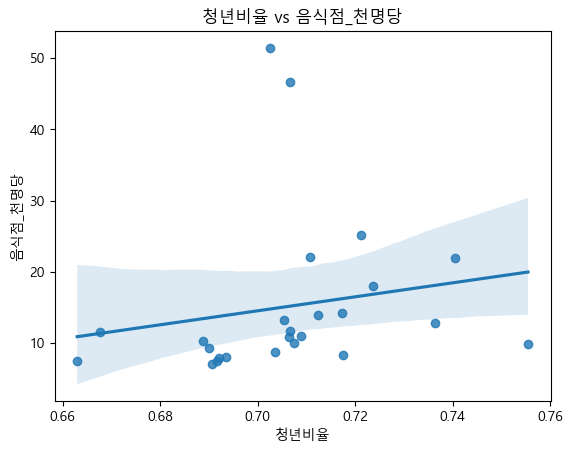

In [59]:
#산점도 + 선형 회귀 모델

'''
청년비율과 음식점 밀도 간에는 Spearman 기준 유의한 양의 상관관계가 나타났으나,
산점도 분석 결과 데이터의 분산이 커 관계의 강도는 제한적인 것으로 판단된다.

따라서 해당 관계는 명확한 인과관계라기보다는
일부 경향성을 나타내는 수준으로 해석하는 것이 적절하다.
'''

sns.regplot(x="청년비율", y="음식점_천명당", data=df)
plt.title("청년비율 vs 음식점_천명당")
plt.show()

In [60]:
df["청년_rank"] = df["청년비율"].rank()
df["음식점_rank"] = df["음식점_천명당"].rank()

df[["구","청년_rank","음식점_rank"]].sort_values("청년_rank")

,구,청년_rank,음식점_rank
9,도봉구,1.0,2.0
8,강북구,2.0,14.0
16,구로구,3.0,11.0
6,중랑구,4.0,8.0
14,양천구,5.0,1.0
10,노원구,6.0,3.0
24,강동구,7.0,4.0
11,은평구,8.0,5.0
1,중구,9.0,25.0
7,성북구,10.0,7.0


In [29]:
'''
서로 다른 시설 지표를 하나의 비교 가능한 점수(편의점수)로 통합
단위는 같아도 분포가 다르기에 그대로 평균내면 왜곡된다
따라서 평균0, 표준편차 1로 변환, 표준화를 진행한다.

편의지수 - 표준화 후 각 시설을 동일 가중치로 반영한 종합 점수
'''


cols = ["병원_천명당", "약국_천명당", "음식점_천명당", "상비약_천명당"]

for col in cols:
    df[col+"_z"] = (df[col] - df[col].mean()) / df[col].std()

df["편의지수"] = df[[c+"_z" for c in cols]].mean(axis=1)
df_rank = df.sort_values("편의지수", ascending=False)

display(df_rank[["구", "편의지수"]])

,구,편의지수
1,중구,3.153674
0,종로구,2.214792
22,강남구,1.531160
13,마포구,0.335209
21,서초구,0.322069
18,영등포구,0.219852
2,용산구,0.071725
5,동대문구,-0.013143
17,금천구,-0.154513
4,광진구,-0.216973


C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


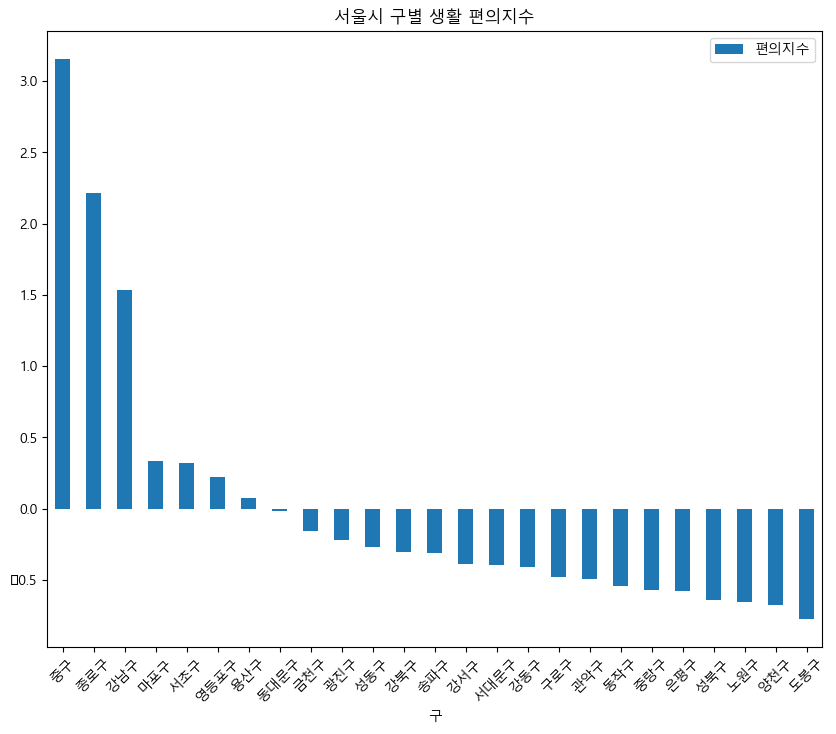

In [39]:
#박스플롯 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'

df_rank.plot(
    x="구",
    y="편의지수",
    kind="bar",   # ← barh → bar
    figsize=(10,8)
)

plt.title("서울시 구별 생활 편의지수")
plt.xticks(rotation=45)  # 글자 겹침 방지
plt.show()

array([[<Axes: title={'center': '병원_천명당'}>,
        <Axes: title={'center': '약국_천명당'}>],
       [<Axes: title={'center': '음식점_천명당'}>,
        <Axes: title={'center': '상비약_천명당'}>]], dtype=object)

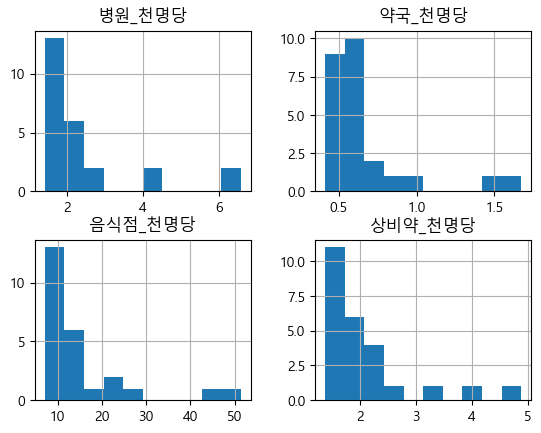

In [33]:
#히스토그램
'''
x축-> 천명당 시설이 몇개 있는가
y축-> 해당 구간에 속하는 구 갯수


히스토그램 분석 결과, 모든 시설은 인구 대비 시설 밀도 기준에서 낮은 값 구간에 다수의 자치구가 집중되어 있으며,
일부 자치구에서 높은 값을 보이는 오른쪽 치우친 분포를 나타낸다.

이는 대부분의 자치구에서 시설 밀도가 유사한 수준을 보이는 반면,
일부 자치구에서 상대적으로 높은 시설 밀도가 나타나 전체 분포에 영향을 미치고 있음을 의미한다.
'''



df[["병원_천명당","약국_천명당","음식점_천명당","상비약_천명당"]].hist()


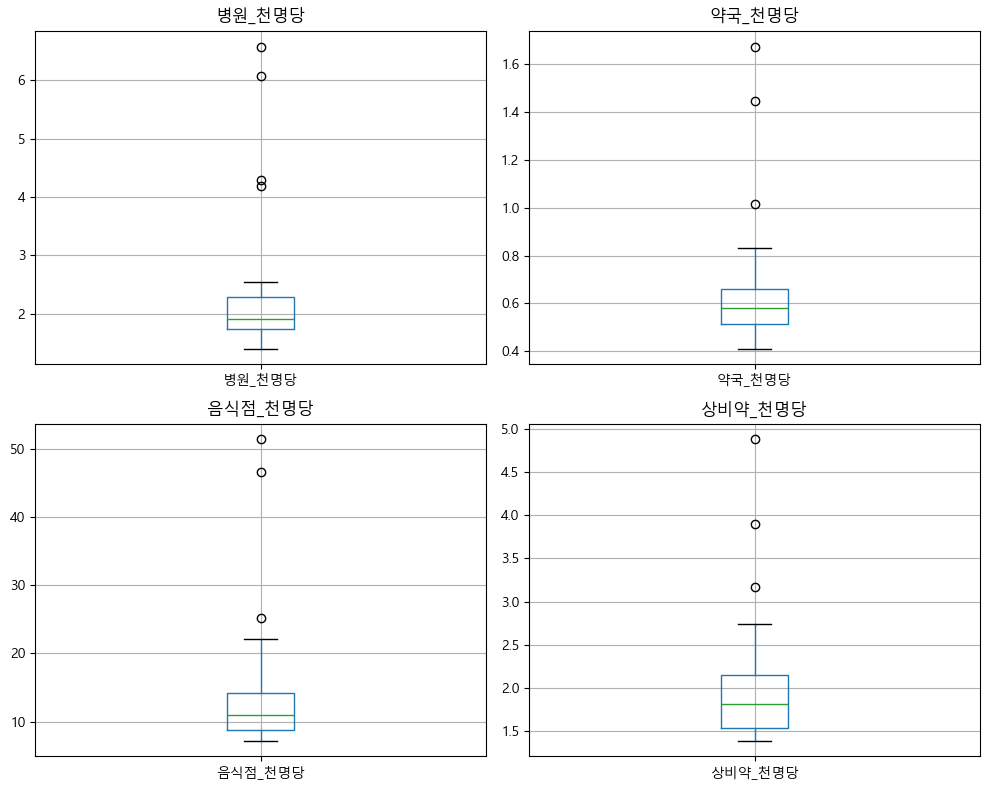

In [44]:
#박스플롯

'''
X축: 시설 종류
Y축: 인구 1000명당 시설 수 (시설 밀도 값)


박스플롯 분석 결과, 일부 자치구에서 시설 밀도가 다른 지역에 비해 크게 높은 이상치가 존재하는 것으로 나타났다.
이는 특정 상업 중심 지역에 시설이 집중되어 있음을 의미한다.
이러한 이상치는 데이터 오류가 아닌 실제 지역 특성을 반영하는 값으로 판단되며, 본 분석에서는 이를 제거하지 않고 포함하였다.
'''
fig, axes = plt.subplots(2, 2, figsize=(10,8))

cols = ["병원_천명당", "약국_천명당", "음식점_천명당", "상비약_천명당"]

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [37]:
#변동계수 cv

'''
CV = 표준편차 / 평균으로 평균 대비 얼마나 퍼져 있는가를 나타낸다.
상대적 변동성 (지역 간 격차)를 의미

음식점   0.74  → 가장 큼
병원     0.55
약국     0.44
상비약   0.40

변동계수(CV) 분석 결과, 음식점의 CV가 0.74로 가장 높게 나타나
자치구 간 분포 격차가 가장 큰 시설임을 확인하였다.

반면 약국과 상비약 판매업소는 상대적으로 낮은 CV 값을 보여
지역 간 분포가 비교적 균등한 것으로 나타났다.

본 분석에서는 자치구 간 인구 규모 차이를 고려하기 위해
시설 수가 아닌 인구 1000명당 시설 수를 기준으로 변동계수를 산출하였다.

'''

for col in ["병원_천명당","약국_천명당","음식점_천명당","상비약_천명당"]:
    cv = df[col].std() / df[col].mean()
    print(col, cv)

병원_천명당 0.5543542580311275
약국_천명당 0.4392179289809152
음식점_천명당 0.7440271847430621
상비약_천명당 0.40420491982467877


In [52]:
#편의 지수에 어떤 시설 지표가 가장 크게 반영되었는가

'''
편의지수와 개별 시설 지표 간 상관분석 결과,
모든 시설 지표가 높은 양의 상관을 보였으며,
이는 해당 지표들이 편의지수 구성에 직접 반영되었기 때문이다.

반면 인구 구조 변수(고령화율, 청년비율, 성비)는
편의지수와 유의한 상관관계를 보이지 않아,
편의 수준이 인구 구조보다는 다른 요인에 의해 결정됨을 시사한다.
'''

cols = [
    "편의지수",
    "병원_천명당",
    "약국_천명당",
    "음식점_천명당",
    "상비약_천명당",
    "고령화율",
    "청년비율",
    "성비",
    "인구"
]
numeric_df = df.select_dtypes(include="number")

numeric_df[cols].corr()["편의지수"].sort_values(ascending=False)

편의지수       1.000000
상비약_천명당    0.981067
약국_천명당     0.975117
음식점_천명당    0.948347
병원_천명당     0.887742
청년비율       0.145976
고령화율      -0.069875
성비        -0.171776
인구        -0.453906
Name: 편의지수, dtype: float64

C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


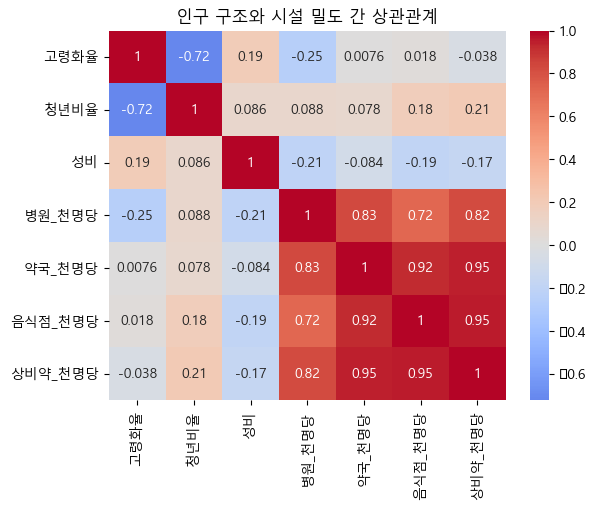

In [73]:
#히트맵


'''
 인구 구조 vs 시설
고령화율, 청년비율, 성비와 시설_천명당 간 상관관계는 전반적으로 낮음
→ 인구 구조가 시설 분포를 직접적으로 설명하지 못함

시설 간 관계
병원, 약국, 음식점, 상비약_천명당 변수 간 높은 양의 상관관계 존재
→ 특정 자치구에 다양한 시설이 함께 집중되는 경향

결론:
시설 분포는 인구 규모나 인구 구조보다는 지역의 상업적/중심지 특성에 의해 결정되는 경향이 큼

'''
cols = [
    "고령화율",
    "청년비율",
    "성비",
    "병원_천명당",
    "약국_천명당",
    "음식점_천명당",
    "상비약_천명당"
]

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("인구 구조와 시설 밀도 간 상관관계")
plt.show()

In [53]:
#편의지수 상위 5개구

top = df.nlargest(5, "편의지수")
print(top)

      구      인구      고령화율      청년비율        성비   병원수  약국수   음식점수  상비약판매업소수  \
1    중구  117762  0.233310  0.702502  0.924373   714  197   6053       575   
0   종로구  136817  0.226653  0.706535  0.918435   572  198   6378       533   
22  강남구  554165  0.174255  0.710705  0.913890  3644  563  12228      1756   
13  마포구  356966  0.174695  0.740409  0.865806   897  228   7848       978   
21  서초구  415540  0.176034  0.705453  0.904592  1785  306   5537       818   

      병원_천명당    약국_천명당    음식점_천명당   상비약_천명당  병원_천명당_z  약국_천명당_z  음식점_천명당_z  \
1   6.063076  1.672866  51.400282  4.882730  2.661302  3.350042   3.206695   
0   4.180767  1.447189  46.617014  3.895715  1.275060  2.590959   2.783207   
22  6.575659  1.015943  22.065630  3.168731  3.038798  1.140430   0.609547   
13  2.512844  0.638716  21.985287  2.739757  0.046704 -0.128401   0.602434   
21  4.295615  0.736391  13.324830  1.968523  1.359641  0.200136  -0.164321   

    상비약_천명당_z      편의지수  
1    3.396657  3.153674  
0    2.209940  2

In [54]:
#편의지수 하위 5개구

bottom = df.nsmallest(5, "편의지수")
print(bottom)

      구      인구      고령화율      청년비율        성비  병원수  약국수  음식점수  상비약판매업소수  \
9   도봉구  299065  0.265374  0.662953  0.930859  419  123  2229       429   
14  양천구  423666  0.202169  0.690591  0.947352  763  200  3018       586   
10  노원구  482487  0.219726  0.691666  0.916547  854  235  3620       670   
7   성북구  422778  0.208954  0.703620  0.913187  627  205  3725       648   
11  은평구  454109  0.228273  0.693448  0.896166  792  233  3687       708   

      병원_천명당    약국_천명당   음식점_천명당   상비약_천명당  병원_천명당_z  약국_천명당_z  음식점_천명당_z  \
9   1.401033  0.411282  7.453229  1.434471 -0.772098 -0.893395  -0.684164   
14  1.800947  0.472070  7.123536  1.383165 -0.477578 -0.688929  -0.713354   
10  1.769996  0.487060  7.502793  1.388638 -0.500372 -0.638510  -0.679776   
7   1.483048  0.484888  8.810771  1.532719 -0.711698 -0.645815  -0.563974   
11  1.744075  0.513093  8.119196  1.559097 -0.519462 -0.550946  -0.625203   

    상비약_천명당_z      편의지수  
9   -0.749286 -0.774736  
14  -0.810973 -0.672708  
10  -0.8

In [30]:
#상위 3등 중구  종로구 강남구
#하위 3등(끝에서부터) 도봉구 양천구 노원구



'''
최종적으로 산출한 생활 편의지수를 서울시 자치구 지도에 시각화하였다.
지도에서 색이 진한 지역일수록 인구 1000명당 병원, 약국, 음식점, 상비약 판매업소를 종합한 생활 편의지수가 높은 지역을 의미한다.

시각화 결과, 중구·종로구·강남구 등 일부 중심 지역에서 높은 편의지수가 나타났으며,
도봉구·양천구·노원구 등 일부 지역은 상대적으로 낮은 값을 보였다.
이는 생활 편의 시설이 서울시 전역에 균등하게 분포하기보다는 특정 자치구에 집중되어 있음을 보여준다.
'''
with open("skorea_municipalities_geo_simple.json", encoding="utf-8") as f:
    geo_data = json.load(f)

m = folium.Map(location=[37.55, 126.98], zoom_start=11)

folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["구", "편의지수"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    legend_name="생활 편의지수"
).add_to(m)

m


# 결론 (확장본)

본 연구는 서울시 자치구별 인구 구조(연령, 성별)와 생활 편의 시설 분포 간의 관계를 정량적으로 분석하는 것을 목적으로 수행되었다.

이를 위해 병원, 약국, 음식점, 상비약 판매업소를 대상으로 인구 1000명당 시설 수를 산출하여 지역 간 비교가 가능하도록 정규화하였으며,
분포 분석, 변동계수(CV), 상관관계 분석(Pearson, Spearman)을 통해 데이터의 구조를 검증하였다.

분석 결과는 다음과 같다.



### 1. 시설 분포의 특징
시설 간 상관관계가 높게 나타나, 특정 자치구에 다양한 시설이 함께 집중되는 경향이 확인되었다.
변동계수 분석 결과, 특히 음식점의 지역 간 격차가 크게 나타나 상업시설이 일부 지역에 집중되어 있음을 확인하였다.



### 2. 인구 구조와 시설 분포 관계
Pearson 상관분석에서는 유의한 관계가 나타나지 않아, 인구 구조가 시설 분포를 직접적으로 설명하지 못하는 것으로 나타났다.
그러나 Spearman 분석에서는 일부 변수(청년비율–음식점, 고령화율–병원) 간 약한 순위 기반 관계가 확인되었다.

→ 이는 인구 구조가 시설 분포에 강한 영향을 주기보다는
일부 경향성 수준에서만 영향을 미칠 수 있음을 의미한다.



### 3. 생활 편의지수 기반 지역 비교
표준화된 시설 밀도를 동일 가중치로 통합하여 생활 편의지수를 산출하였다.
그 결과, 중구·종로구·강남구 등 중심 지역에서 높은 편의 수준이 나타났으며,
도봉구·양천구·노원구 등 일부 지역은 상대적으로 낮은 값을 보였다.

→ 이는 생활 편의 시설이 균등하게 분포하기보다
상업 중심지 및 도심 지역에 집중되는 구조를 보여준다.



### 최종 해석

본 분석 결과, 서울시 생활 편의 수준은 인구 규모나 연령 구조보다
지역의 기능적 특성(상업 중심지 여부 등)에 의해 결정되는 경향이 더 크다.

분석 결과, 일부 중심 지역에 시설이 집중되고 외곽 지역에서는 상대적으로 부족한 경향이 확인되었다.
이에 따라 편의지수가 낮은 자치구를 중심으로 시설 확충 우선순위를 설정할 수 있으며,
특히 지역 간 격차가 큰 음식점과 일부 의료시설에 대해 분산 배치 정책을 고려할 수 있다.

다만 본 연구는 시설의 질, 이용량, 접근성 등을 반영하지 못하므로
구체적인 입지 선정이나 정책 결정에는 추가적인 데이터 분석이 필요하다.




### 향후 개선 방향 (데이터 기반 한계 포함)
현재 분석은 시설의 “수”만을 기반으로 하므로 다음과 같은 한계가 존재한다.

시설의 규모 및 질(병원 규모, 음식점 종류 등) 미반영
실제 이용량 또는 유동 인구 데이터 부재
거리 기반 접근성(접근 시간, 이동 거리) 미반영

따라서 향후에는 다음과 같은 분석이 필요하다.

유동 인구 데이터를 활용한 수요 기반 분석
거리 기반 접근성 분석(GIS 활용)
시설 유형 세분화(의료기관 종류, 음식점 카테고리 등)

'''